In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv(r"C:\Users\dorap\Downloads\inv\house-prices-advanced-regression-techniques\train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
X=df[['GrLivArea','OverallQual','GarageCars','TotalBsmtSF']]
Y=df['SalePrice']

In [7]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,
    test_size=0.2,
    random_state=42
)

In [11]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)
y_pred = model.predict(X_test)

In [16]:
mae=mean_absolute_error(Y_test,y_pred)
print(mae)
mse=mean_squared_error(Y_test,y_pred)
print(mse)

25446.054739212483
1602914819.4438987


In [17]:
rmse=np.sqrt(mse)
print(rmse)
r2=r2_score(Y_test,y_pred)
print(r2)

40036.41866406008
0.791023904831849


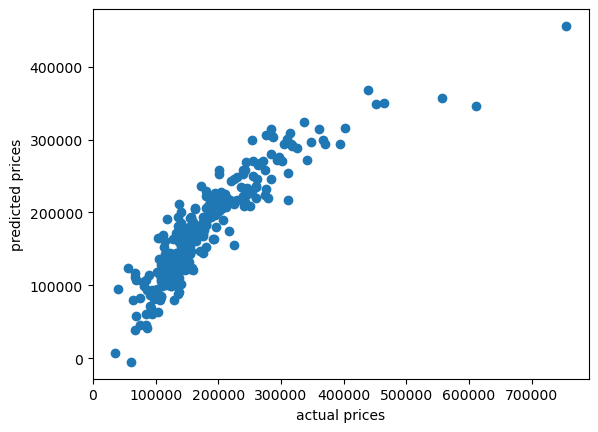

In [19]:
plt.scatter(Y_test,y_pred)
plt.xlabel("actual prices")
plt.ylabel("predicted prices")
plt.show()

In [21]:
residuals=Y_test-y_pred

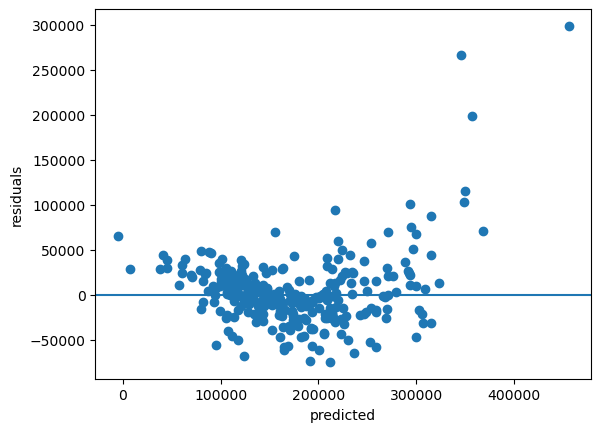

In [23]:
plt.scatter(y_pred,residuals)
plt.axhline(y=0)
plt.xlabel("predicted")
plt.ylabel("residuals")
plt.show()

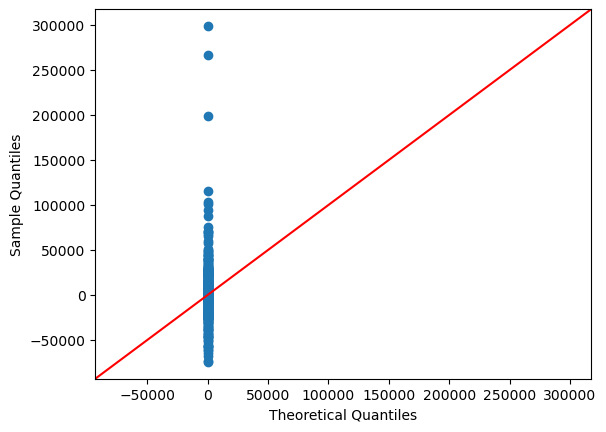

In [25]:
import statsmodels.api as sm
sm.qqplot(residuals,line='45')
plt.show()

In [29]:
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print("Durbin-Watson Statistic:", dw)

Durbin-Watson Statistic: 1.926156568502337


In [30]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=1.0)
ridge.fit(X_train,Y_train)
ridge_pred=ridge.predict(X_test)
print(r2_score(Y_test,ridge_pred))

0.7910504051955143


In [31]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=1.0)
lasso.fit(X_train,Y_train)
lasso_pred=lasso.predict(X_test)
print(r2_score(Y_test,lasso_pred))

0.7910253686716113
